# Phase 4 — VideoLights Re-Filtrage des Highlights

```
Phase 1  →  Geometric Filter (pairwise, NMS)        
Phase 2  →  Re-ranker ImageBind (zero-shot/MLP)     
Phase 3  →  Assemblage du short (cuts + xfade)     
Phase 4  →  VideoLights HD re-scoring               
```

**Stratégie Phase 4 :**
1. Charger les segments Phase 2 (`_phase2_highlights.npz`)
2. Assembler les segments chronologiquement → `_assembled_highlights.mp4`
3. Extraire des features CLIP (ViT-B/32) par clip de 2s sur la vidéo assemblée
4. Charger le modèle VideoLights (checkpoint QVHighlights) et scorer chaque segment
5. Re-filtrer selon le saliency score VideoLights
6. Assembler le short final re-filtré

**Pourquoi assembler avant ?**  
VideoLights travaille sur des features temporelles continues. En assemblant les segments
highlights avant l'inférence, on donne au modèle le contexte temporel correct pour évaluer
la saillance relative de chaque moment dans la séquence réduite.



In [1]:
# ============================================================
# CELL 1 : Mount Drive + Chemins + Config
# ============================================================
import sys, os
from google.colab import drive

drive.mount('/content/drive')

PROJECT_ROOT   = '/content/drive/MyDrive/PFA'
IMAGEBIND_ROOT = '/content/drive/MyDrive/PFA/ImageBind'
LIB_ROOT       = '/content/drive/MyDrive/PFA/ImageBind/ImageBind'

for p in [LIB_ROOT, IMAGEBIND_ROOT, PROJECT_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

INPUT_DIR  = os.path.join(PROJECT_ROOT, 'data')
OUTPUT_DIR = os.path.join(IMAGEBIND_ROOT, 'results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_VIDEO = 'Obama_Yes_we_can.mp4'   # ← changer si nécessaire
VIDEO_PATH   = os.path.join(INPUT_DIR, TARGET_VIDEO)
VIDEO_STEM   = os.path.splitext(TARGET_VIDEO)[0]

# ── Chemins Phase 2 (inputs) ───────────────────────────────
P2_PATH = os.path.join(OUTPUT_DIR, VIDEO_STEM + '_phase2_highlights.npz')

# ── Config Phase 4 ─────────────────────────────────────────
CFG4 = dict(
    # VideoLights
    VL_CHECKPOINT_ID  = '1xLWu7F0OxDO8DW3JOZ3THiOw0FFs1dC-',  # VideoLights-B-pt (best)
    VL_REPO_DIR       = '/content/VideoLights',
    VL_CLIP_LEN_S     = 2.0,        # secondes par clip CLIP-feature
    VL_QUERY          = 'exciting highlight moment',  # texte query pour HD
    VL_SALIENCY_THRESH = 0.35,      # seuil saliency score VideoLights [0..1]
    VL_TOP_K          = None,       # si None → utilise le seuil, sinon prend top-K
    # Assemblage
    FADE_DURATION_S   = 0.5,
    OUTPUT_RESOLUTION = '1080x1920',
    OUTPUT_FPS        = 30,
    TARGET_DURATION_S = 60,
    ADD_CAPTIONS      = True,
)

print('✅ Config Phase 4 chargée')
for k, v in CFG4.items():
    print(f'  {k:<25} = {v}')

Mounted at /content/drive
✅ Config Phase 4 chargée
  VL_CHECKPOINT_ID          = 1xLWu7F0OxDO8DW3JOZ3THiOw0FFs1dC-
  VL_REPO_DIR               = /content/VideoLights
  VL_CLIP_LEN_S             = 2.0
  VL_QUERY                  = exciting highlight moment
  VL_SALIENCY_THRESH        = 0.35
  VL_TOP_K                  = None
  FADE_DURATION_S           = 0.5
  OUTPUT_RESOLUTION         = 1080x1920
  OUTPUT_FPS                = 30
  TARGET_DURATION_S         = 60
  ADD_CAPTIONS              = True


In [2]:
# ============================================================
# CELL 2 : Dépendances
# ============================================================
!pip install -q moviepy==1.0.3 ftfy regex tqdm gdown
!pip install -q git+https://github.com/openai/CLIP.git

import numpy as np
import torch
import torch.nn.functional as F
import subprocess, shutil, json, time
from pathlib import Path

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print('✅ Dépendances OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Device : cuda
✅ Dépendances OK


In [3]:
# ============================================================
# CELL 3 : Cloner VideoLights + télécharger le checkpoint
# ============================================================
import gdown, zipfile

VL_REPO = CFG4['VL_REPO_DIR']

if not os.path.exists(VL_REPO):
    print('Clonage VideoLights...')
    !git clone https://github.com/dpaul06/VideoLights.git {VL_REPO} -q
else:
    print('VideoLights déjà cloné')

if VL_REPO not in sys.path:
    sys.path.insert(0, VL_REPO)

!pip install -q -r {VL_REPO}/requirements.txt 2>/dev/null || true

# ── Télécharger le checkpoint depuis HuggingFace ──────────
CKPT_DIR  = os.path.join(VL_REPO, 'checkpoints')
CKPT_PATH = os.path.join(CKPT_DIR, 'VideoLights-B-pt.ckpt')
os.makedirs(CKPT_DIR, exist_ok=True)

HF_ZIP_URL = (
    'https://huggingface.co/dpaul06/VideoLights/resolve/main/'
    'Checkpoints/QVHighlights/VideoLights-B-pt.zip'
)
ZIP_PATH = os.path.join(CKPT_DIR, 'VideoLights-B-pt.zip')

if not os.path.exists(CKPT_PATH):
    print('Téléchargement checkpoint VideoLights-B-pt depuis HuggingFace...')
    !wget -q --show-progress -O "{ZIP_PATH}" "{HF_ZIP_URL}"

    # ── Extraire le .ckpt depuis le ZIP ───────────────────
    print('Extraction du checkpoint...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        print(f'  Contenu ZIP : {zf.namelist()}')
        # Trouver le fichier modèle (.ckpt ou .pth) dans le ZIP
        model_files = [m for m in zf.namelist()
                       if m.endswith('.ckpt') or m.endswith('.pth')]
        if not model_files:
            raise RuntimeError(f'Aucun .ckpt/.pth dans le ZIP : {zf.namelist()}')
        # Extraire dans CKPT_DIR et renommer proprement
        zf.extract(model_files[0], CKPT_DIR)
        extracted_path = os.path.join(CKPT_DIR, model_files[0])
        if extracted_path != CKPT_PATH:
            os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
            os.rename(extracted_path, CKPT_PATH)

    os.remove(ZIP_PATH)  # nettoyer le ZIP
    print(f'✅ Checkpoint extrait : {CKPT_PATH}')

    # Vérification : s'assurer que c'est bien un fichier PyTorch
    file_size_mb = os.path.getsize(CKPT_PATH) / 1e6
    print(f'   Taille : {file_size_mb:.1f} MB')
    if file_size_mb < 10:
        print('⚠️  Fichier trop petit — vérifier le téléchargement')
else:
    print(f'Checkpoint déjà présent : {CKPT_PATH}')

print('✅ VideoLights prêt')

Clonage VideoLights...
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Téléchargement checkpoint VideoLights-B-pt depuis HuggingFace...
/content/VideoLight 100%[===================>] 113.65M  38.3MB/s    in 3.0s    
Extraction du checkpoint...
  Contenu ZIP : ['VideoLights-B-pt/', 'VideoLights-B-pt/opt.json', 'VideoLights-B-pt/train.log.txt', 'VideoLights-B-pt/best_hl_val_preds.jsonl', 'VideoLights-B-pt/best_hl_val_preds_metrics.json', 'VideoLights-B-pt/eval.log.txt', 'VideoLights-B-pt/model_best.ckpt', 'VideoLights-B-pt/latest_hl_val_preds.jsonl', 'VideoLights-B-pt/latest_hl_val_preds_metrics.json', 'VideoLights-B-pt/hl_val_submission.jsonl', 'VideoLights-B-pt/hl_val_submission_metrics.json', 'VideoLights-B-pt/hl_test_submission.jsonl', 'VideoLights-B-pt/hl_submission.zip', 'VideoLights-B-pt/code.zip', 'VideoLights-B-pt/tensorboard_

In [4]:
# ============================================================
# CELL 4 : Charger les highlights Phase 2
# ============================================================
p2 = np.load(P2_PATH, allow_pickle=True)

hl_times_p2  = p2['times']       # [K, 2]
hl_scores_p2 = p2['final_score'] # [K]
hl_texts_p2  = p2['raw_text']    # [K]
hl_pairs_p2  = p2['pair_idx']    # [K]

# Tri chronologique
chron_idx    = np.argsort(hl_times_p2[:, 0])
hl_times     = hl_times_p2[chron_idx]
hl_scores    = hl_scores_p2[chron_idx]
hl_texts     = hl_texts_p2[chron_idx]
K            = len(hl_times)

print(f'Phase 2 → {K} segments highlights chargés')
print(f'{"#":<4} {"Start":>7} {"End":>7}  {"Durée":>7}  {"Score":>7}')
print('-' * 45)
for i in range(K):
    s, e = hl_times[i]
    print(f'#{i+1:<3} {s:>6.1f}s {e:>6.1f}s  {e-s:>6.1f}s  {hl_scores[i]:>7.3f}')
print(f'\nDurée totale brute : {(hl_times[:,1]-hl_times[:,0]).sum():.1f}s')

Phase 2 → 5 segments highlights chargés
#      Start     End    Durée    Score
---------------------------------------------
#1     14.0s   17.0s     3.0s    0.579
#2     27.0s   30.0s     3.0s    0.569
#3     45.0s   48.0s     3.0s    0.560
#4     59.0s   62.0s     3.0s    0.548
#5     74.0s   77.0s     3.0s    0.567

Durée totale brute : 15.0s


In [5]:
# ============================================================
# CELL 5 : Assembler les segments → vidéo d'entrée VideoLights
# ============================================================
# VideoLights attend une vidéo continue → on assemble les highlights
# chronologiquement avec une coupe sèche (pas de xfade ici, pour
# ne pas perturber les timestamps utilisés pour le scoring)

ASSEMBLE_DIR  = '/tmp/vl_clips'
os.makedirs(ASSEMBLE_DIR, exist_ok=True)

ASSEMBLED_VIDEO = os.path.join(OUTPUT_DIR, VIDEO_STEM + '_assembled_highlights.mp4')

def extract_clip_raw(video_path, start_s, end_s, out_path):
    """Découpe un segment sans recadrage (vidéo brute pour feature extraction)."""
    dur = end_s - start_s
    cmd = [
        'ffmpeg', '-y', '-ss', str(start_s), '-i', video_path,
        '-t', str(dur),
        '-c:v', 'libx264', '-preset', 'fast', '-crf', '18',
        '-c:a', 'aac', '-b:a', '128k',
        out_path, '-loglevel', 'error'
    ]
    subprocess.run(cmd, check=True)

def concat_clips(clip_paths, output_path):
    """Concatène une liste de clips via un fichier liste ffmpeg."""
    list_file = '/tmp/vl_concat_list.txt'
    with open(list_file, 'w') as f:
        for p in clip_paths:
            f.write(f"file '{p}'\n")
    cmd = [
        'ffmpeg', '-y', '-f', 'concat', '-safe', '0',
        '-i', list_file,
        '-c', 'copy',
        output_path, '-loglevel', 'error'
    ]
    subprocess.run(cmd, check=True)

# ── Extraire chaque segment ────────────────────────────────
clip_paths_raw = []
# Table de correspondance : offset dans la vidéo assemblée → segment original
assembled_segments = []  # [(assembled_start, assembled_end, original_start, original_end, text)]
current_offset = 0.0

for i, (start_s, end_s) in enumerate(hl_times):
    dur = end_s - start_s
    clip_path = os.path.join(ASSEMBLE_DIR, f'seg_{i:02d}.mp4')
    extract_clip_raw(VIDEO_PATH, start_s, end_s, clip_path)
    clip_paths_raw.append(clip_path)
    assembled_segments.append((
        current_offset,
        current_offset + dur,
        float(start_s),
        float(end_s),
        str(hl_texts[i]),
        float(hl_scores[i])
    ))
    current_offset += dur
    print(f'  Segment {i+1:02d}: [{start_s:.1f}s → {end_s:.1f}s]  ({dur:.1f}s) extrait')

# ── Concaténer ────────────────────────────────────────────
concat_clips(clip_paths_raw, ASSEMBLED_VIDEO)
total_assembled = current_offset

print(f'\n✅ Vidéo assemblée : {ASSEMBLED_VIDEO}')
print(f'   Durée totale assemblée : {total_assembled:.1f}s ({K} segments)')

# Sauvegarder la table de correspondance
seg_map = assembled_segments  # utilisé plus bas pour mapper les scores VL

  Segment 01: [14.0s → 17.0s]  (3.0s) extrait
  Segment 02: [27.0s → 30.0s]  (3.0s) extrait
  Segment 03: [45.0s → 48.0s]  (3.0s) extrait
  Segment 04: [59.0s → 62.0s]  (3.0s) extrait
  Segment 05: [74.0s → 77.0s]  (3.0s) extrait

✅ Vidéo assemblée : /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_assembled_highlights.mp4
   Durée totale assemblée : 15.0s (5 segments)


In [9]:
# ============================================================
# CELL 6 : Extraire les features CLIP (ViT-B/32) par fenêtre de 2s
# ============================================================
# VideoLights attend en entrée des features CLIP (dim=512) par clip de 2s
# C'est le même format que QVHighlights.

import clip
import cv2
from PIL import Image

print('Chargement CLIP ViT-B/32...')
clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()
print('✅ CLIP chargé')

def extract_clip_features_from_video(video_path, clip_len_s=2.0, device='cpu'):
    """
    Extrait des features CLIP ViT-B/32 pour chaque fenêtre de clip_len_s secondes.
    Retourne:
      features  : np.ndarray [N_clips, 512]
      timestamps: list de (start_s, end_s) pour chaque clip
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_s   = total_frames / fps
    frames_per_clip = max(1, int(fps * clip_len_s))

    all_features = []
    timestamps   = []
    clip_idx     = 0

    print(f'  Vidéo: {duration_s:.1f}s | {fps:.1f}fps | {total_frames} frames')
    print(f'  Fenêtre: {clip_len_s}s = {frames_per_clip} frames/clip')

    frame_buffer = []
    frame_count  = 0
    clip_start_frame = 0

    with torch.no_grad():
        while True:
            ret, frame = cap.read()
            if not ret:
                # Traiter le dernier buffer partiel s'il reste des frames
                if frame_buffer:
                    mid_frame = frame_buffer[len(frame_buffer)//2]
                    img = Image.fromarray(cv2.cvtColor(mid_frame, cv2.COLOR_BGR2RGB))
                    inp = clip_preprocess(img).unsqueeze(0).to(device)
                    feat = clip_model.encode_image(inp).squeeze(0).float().cpu().numpy()
                    all_features.append(feat)
                    t_start = clip_start_frame / fps
                    t_end   = frame_count / fps
                    timestamps.append((t_start, t_end))
                break

            frame_buffer.append(frame)
            frame_count += 1

            if len(frame_buffer) >= frames_per_clip:
                # Prendre la frame centrale du clip comme représentant
                mid_frame = frame_buffer[frames_per_clip // 2]
                img = Image.fromarray(cv2.cvtColor(mid_frame, cv2.COLOR_BGR2RGB))
                inp = clip_preprocess(img).unsqueeze(0).to(device)
                feat = clip_model.encode_image(inp).squeeze(0).float().cpu().numpy()
                all_features.append(feat)
                t_start = clip_start_frame / fps
                t_end   = frame_count / fps
                timestamps.append((t_start, t_end))
                clip_start_frame = frame_count
                frame_buffer = []
                clip_idx += 1

    cap.release()
    features = np.stack(all_features, axis=0)  # [N_clips, 512]
    print(f'  → {len(all_features)} clips features extraites  shape={features.shape}')
    return features, timestamps


print('\nExtraction features CLIP sur vidéo assemblée...')
vl_features, vl_timestamps = extract_clip_features_from_video(
    ASSEMBLED_VIDEO,
    clip_len_s=CFG4['VL_CLIP_LEN_S'],
    device=DEVICE
)
print(f'\n✅ Features CLIP extraites : {vl_features.shape}')

Chargement CLIP ViT-B/32...


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 109MiB/s]


✅ CLIP chargé

Extraction features CLIP sur vidéo assemblée...
  Vidéo: 15.0s | 24.0fps | 360 frames
  Fenêtre: 2.0s = 48 frames/clip
  → 8 clips features extraites  shape=(8, 512)

✅ Features CLIP extraites : (8, 512)


In [15]:
# ============================================================
# CELL 7 : Extraire la feature texte CLIP (query VideoLights)
# ============================================================
QUERY = CFG4['VL_QUERY']

with torch.no_grad():
    text_tokens = clip.tokenize([QUERY]).to(DEVICE)
    query_feat  = clip_model.encode_text(text_tokens).squeeze(0).float().cpu().numpy()

print(f'Query : "{QUERY}"')
print(f'Feature texte shape : {query_feat.shape}')  # [512]

Query : "exciting highlight moment"
Feature texte shape : (512,)


In [16]:
# ============================================================
# CELL 8 modifiée : Trouver et ajouter l'adaptateur
# ============================================================

if VL_NATIVE:
    print('Chargement checkpoint...')
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

    # ... (votre code de chargement existant) ...

    try:
        vl_model, _ = build_model(opt)
        vl_model.load_state_dict(ckpt['model'], strict=False)
        vl_model = vl_model.to(DEVICE)

        # ======================================================
        # 🔍 EXPLORER L'ARCHITECTURE DU MODÈLE
        # ======================================================
        print("\n🔍 Architecture du modèle VideoLights:")
        print("=" * 60)

        # Afficher les modules principaux
        for name, module in vl_model.named_children():
            print(f"  {name}: {type(module).__name__}")

        print("\n🔍 Recherche de couches Linear dans le modèle:")
        print("=" * 60)

        # Chercher toutes les couches Linear pour trouver la projection vidéo
        for name, module in vl_model.named_modules():
            if isinstance(module, torch.nn.Linear):
                print(f"  {name}: in={module.in_features}, out={module.out_features}")

        # ======================================================
        # 🔧 AJOUT DE L'ADAPTATEUR
        # ======================================================
        print("\n🔧 Installation de l'adaptateur CLIP...")

        # Option 1: Ajouter une projection avant l'encodeur vidéo
        class ClipAdapterWrapper(torch.nn.Module):
            def __init__(self, original_model, target_dim=512):
                super().__init__()
                self.original_model = original_model
                # Projection 512 → 3586 (ou dimension attendue)
                self.projection = torch.nn.Linear(512, target_dim)

            def forward(self, src_vid, src_vid_mask, src_txt, src_txt_mask):
                # Projeter les features vidéo
                src_vid = self.projection(src_vid)
                return self.original_model(src_vid, src_vid_mask, src_txt, src_txt_mask)

        # Trouver la dimension d'entrée du modèle
        sample_input = torch.randn(1, 8, 512).to(DEVICE)  # Batch=1, 8 clips, 512 dims
        with torch.no_grad():
            try:
                # Tester avec une entrée pour voir la dimension attendue
                test_output = vl_model.module if hasattr(vl_model, 'module') else vl_model
                print(f"  Modèle wrapper: {hasattr(vl_model, 'module')}")
            except:
                pass

        # Remplacer le modèle par une version avec adaptateur
        original_forward = vl_model.forward

        def adapted_forward(src_vid, src_vid_mask, src_txt, src_txt_mask):
            # src_vid vient avec dim 512, on projette vers dim cible
            if src_vid.shape[-1] == 512:
                # Créer une projection si pas encore faite
                if not hasattr(vl_model, 'clip_adapter'):
                    target_dim = 3586  # Dimension attendue par VideoLights
                    vl_model.clip_adapter = torch.nn.Linear(512, target_dim).to(src_vid.device)
                    print(f"  ✅ Adaptateur créé: Linear(512 → {target_dim})")
                src_vid = vl_model.clip_adapter(src_vid)
            return original_forward(src_vid, src_vid_mask, src_txt, src_txt_mask)

        vl_model.forward = adapted_forward

        vl_model.eval()
        print(f'\n✅ Modèle VideoLights chargé AVEC adaptateur CLIP !')

    except Exception as e:
        print(f'⚠️ Erreur : {e}')
        vl_model = None

Chargement checkpoint...

🔍 Architecture du modèle VideoLights:
  transformer: VLTransformer
  position_embed: PositionEmbeddingSine
  txt_position_embed: TrainablePositionalEncoding
  span_embed: MLP
  class_embed: Linear
  query_embed: Embedding
  input_txt_proj: Sequential
  input_vid_proj: Sequential
  contrastive_align_projection_query: Linear
  contrastive_align_projection_txt: Linear
  contrastive_align_projection_vid: Linear
  feature_refinement: FeatureRefinement
  saliency_proj1: Linear
  saliency_proj2: Linear
  gru_extractor: GlobalFeatureExtractor
  saliency_proj_mr: Linear

🔍 Recherche de couches Linear dans le modèle:
  transformer.t2v_encoder.layers.0.cross_attn_1.out_proj: in=256, out=256
  transformer.t2v_encoder.layers.0.cross_attn_2.out_proj: in=256, out=256
  transformer.t2v_encoder.layers.0.cross_attn_3.out_proj: in=256, out=256
  transformer.t2v_encoder.layers.0.linear1: in=256, out=256
  transformer.t2v_encoder.layers.0.linear2: in=256, out=256
  transformer.t2v

In [21]:
# ============================================================
# CELL 8 : Chargement VideoLights avec ADAPTATEUR COMPLET (VIDÉO + TEXTE)
# ============================================================
import zipfile, json
from types import SimpleNamespace

VL_REPO      = CFG4['VL_REPO_DIR']
CKPT_DIR     = os.path.join(VL_REPO, 'checkpoints')
CKPT_PATH    = os.path.join(CKPT_DIR, 'VideoLights-B-pt.ckpt')

if VL_REPO not in sys.path:
    sys.path.insert(0, VL_REPO)

# ── Import des modules VideoLights ────────────────────────
try:
    from video_lights.config import BaseOptions
    from video_lights.model  import build_model
    VL_NATIVE = True
    print('✅ VideoLights importé via modules natifs')
except ImportError as e:
    VL_NATIVE = False
    print(f'⚠️  Import natif échoué ({e})')

if VL_NATIVE:
    print('Chargement checkpoint...')
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    print(f'  Clés checkpoint : {list(ckpt.keys())}')

    # ── Récupérer les options ───────────────────────────────
    if 'opt' in ckpt:
        opt = ckpt['opt']
        print('  Options ← ckpt["opt"]')
    else:
        opt = BaseOptions().parse(args=[])
        print('  Options ← BaseOptions défaut')

    # ── Ajouter les attributs manquants ──────────────────────
    missing_attrs = {
        'mr_to_hd_loss': False,
        'mr_to_hd_loss_coef': 0.0,
        'cos_sim_loss_coef': 0.0,
        'hard_pos_neg_loss': False,
        'hard_pos_neg_loss_coef': 0.0,
        'n_epoch': 100,
        'clip_length': 2.0,
        'input_dim': 3586,
        'txt_dim': 1280,  # Dimension attendue pour le texte
    }

    for attr, default in missing_attrs.items():
        if not hasattr(opt, attr):
            setattr(opt, attr, default)
            print(f'  → Ajout attribut : {attr}={default}')

    if not hasattr(opt, 'device'):
        opt.device = DEVICE

    # ── Build et chargement du modèle ────────────────────────
    vl_model, _ = build_model(opt)
    vl_model.load_state_dict(ckpt['model'], strict=False)
    vl_model = vl_model.to(DEVICE)

    # ==========================================================
    # 🔧 ADAPTATEURS COMPLETS (VIDÉO + TEXTE)
    # ==========================================================
    print("\n🔧 Installation des adaptateurs CLIP...")

    # Dimensions
    VIDEO_TARGET_DIM = 3586  # Dimension attendue par VideoLights pour la vidéo
    TEXT_TARGET_DIM = 1280   # Dimension attendue par VideoLights pour le texte

    # 1. ADAPTATEUR VIDÉO
    original_vid_proj = vl_model.input_vid_proj

    class VideoClipAdapter(torch.nn.Module):
        def __init__(self, original_proj, target_dim, device):
            super().__init__()
            self.adapter = torch.nn.Linear(512, target_dim).to(device)
            self.original_proj = original_proj

        def forward(self, x):
            original_shape = x.shape
            if x.dim() == 3:
                x = x.view(-1, 512)
            x = self.adapter(x)
            if len(original_shape) == 3:
                x = x.view(original_shape[0], original_shape[1], -1)
            return self.original_proj(x)

    vl_model.input_vid_proj = VideoClipAdapter(original_vid_proj, VIDEO_TARGET_DIM, DEVICE)
    print(f"  ✅ Adaptateur vidéo: Linear(512 → {VIDEO_TARGET_DIM})")

    # 2. ADAPTATEUR TEXTE
    # Le modèle a input_txt_proj pour le texte
    original_txt_proj = vl_model.input_txt_proj

    class TextClipAdapter(torch.nn.Module):
        def __init__(self, original_proj, target_dim, device):
            super().__init__()
            self.adapter = torch.nn.Linear(512, target_dim).to(device)
            self.original_proj = original_proj

        def forward(self, x):
            original_shape = x.shape
            # Texte: souvent [batch, seq_len, 512] ou [batch, 512]
            if x.dim() == 3:
                x = x.view(-1, 512)
            elif x.dim() == 2:
                pass  # [batch, 512] déjà
            x = self.adapter(x)
            if len(original_shape) == 3:
                x = x.view(original_shape[0], original_shape[1], -1)
            return self.original_proj(x)

    vl_model.input_txt_proj = TextClipAdapter(original_txt_proj, TEXT_TARGET_DIM, DEVICE)
    print(f"  ✅ Adaptateur texte: Linear(512 → {TEXT_TARGET_DIM})")

    # Tout remettre sur le bon device
    vl_model = vl_model.to(DEVICE)
    vl_model.eval()

    # Vérification
    print(f"\n✅ Modèle VideoLights chargé AVEC adaptateurs CLIP !")
    print(f"   Device du modèle: {next(vl_model.parameters()).device}")
    print(f"   epoch={ckpt.get('epoch', '?')}")

if not VL_NATIVE:
    vl_model = None
    print('\n⚠️ Fallback CLIP cosine activé')

✅ VideoLights importé via modules natifs
Chargement checkpoint...
  Clés checkpoint : ['model', 'optimizer', 'lr_scheduler', 'epoch', 'opt']
  Options ← ckpt["opt"]
  → Ajout attribut : mr_to_hd_loss_coef=0.0
  → Ajout attribut : input_dim=3586
  → Ajout attribut : txt_dim=1280

🔧 Installation des adaptateurs CLIP...
  ✅ Adaptateur vidéo: Linear(512 → 3586)
  ✅ Adaptateur texte: Linear(512 → 1280)

✅ Modèle VideoLights chargé AVEC adaptateurs CLIP !
   Device du modèle: cuda:0
   epoch=74


In [22]:
# ============================================================
# CELL 9 : Inférence VideoLights avec adaptateurs CLIP
# ============================================================

# S'assurer que la query est définie
QUERY = CFG4['VL_QUERY']

# Extraire la feature texte
print(f'Extraction feature texte pour : "{QUERY}"')
with torch.no_grad():
    text_tokens = clip.tokenize([QUERY]).to(DEVICE)
    query_feat = clip_model.encode_text(text_tokens).squeeze(0).float().cpu().numpy()
    print(f'  Shape CLIP: {query_feat.shape}')  # 512

def run_videolights_inference(vl_model, vl_features, query_feat, device):
    N = vl_features.shape[0]

    if vl_model is not None:
        print('Inférence VideoLights (avec adaptateurs CLIP)...')

        # Vidéo: [1, N, 512]
        vid_t = torch.tensor(vl_features, dtype=torch.float32).to(device).unsqueeze(0)

        # Texte: [1, 1, 512] (batch=1, seq_len=1, dim=512)
        qry_t = torch.tensor(query_feat, dtype=torch.float32).to(device).unsqueeze(0).unsqueeze(0)

        print(f'  Input vidéo shape: {vid_t.shape}')
        print(f'  Input texte shape: {qry_t.shape}')

        vid_mask = torch.ones(1, N, dtype=torch.bool).to(device)
        qry_mask = torch.ones(1, 1, dtype=torch.bool).to(device)

        with torch.no_grad():
            try:
                outputs = vl_model(
                    src_vid=vid_t,
                    src_vid_mask=vid_mask,
                    src_txt=qry_t,
                    src_txt_mask=qry_mask
                )

                if 'saliency_scores' in outputs:
                    sal = outputs['saliency_scores'].squeeze().cpu().numpy()
                elif 'pred_saliency_scores' in outputs:
                    sal = outputs['pred_saliency_scores'].squeeze().cpu().numpy()
                else:
                    sal = outputs['pred_logits'].squeeze().sigmoid().cpu().numpy()
                    sal = sal[:N] if len(sal) >= N else np.pad(sal, (0, N - len(sal)))

                print(f'  ✅ Saliency scores VideoLights : shape={sal.shape}')

                sal_min, sal_max = sal.min(), sal.max()
                if sal_max > sal_min:
                    sal_norm = (sal - sal_min) / (sal_max - sal_min)
                else:
                    sal_norm = np.ones_like(sal) * 0.5
                return sal_norm

            except Exception as e:
                print(f'  ⚠️ Erreur inférence : {e}')
                import traceback
                traceback.print_exc()
                print('  → Fallback CLIP cosine')

    # Fallback
    print('\n📌 Fallback CLIP cosine...')
    vid_norm = F.normalize(torch.tensor(vl_features, dtype=torch.float32), dim=-1)
    qry_norm = F.normalize(torch.tensor(query_feat, dtype=torch.float32).unsqueeze(0), dim=-1)
    cosine_sal = (vid_norm @ qry_norm.T).squeeze(1).numpy()

    inter_clip_sim = np.zeros(N)
    for i in range(N):
        neighbors = []
        if i > 0: neighbors.append(float((vid_norm[i] * vid_norm[i-1]).sum()))
        if i < N-1: neighbors.append(float((vid_norm[i] * vid_norm[i+1]).sum()))
        inter_clip_sim[i] = np.mean(neighbors) if neighbors else 0.0

    sal = 0.7 * cosine_sal + 0.3 * inter_clip_sim
    sal_min, sal_max = sal.min(), sal.max()
    if sal_max > sal_min:
        sal_norm = (sal - sal_min) / (sal_max - sal_min)
    else:
        sal_norm = np.ones_like(sal) * 0.5
    return sal_norm

print("\n" + "="*60)
print("Calcul des scores de saillance avec VideoLights...")
print("="*60)
vl_saliency = run_videolights_inference(vl_model, vl_features, query_feat, DEVICE)

print(f'\n✅ Saliency scores : shape={vl_saliency.shape}')
print(f'  mean={vl_saliency.mean():.3f}  std={vl_saliency.std():.3f}')
print(f'  min={vl_saliency.min():.3f}   max={vl_saliency.max():.3f}')

print(f'\n📊 Scores par clip temporel (2s chacun) :')
for i, (start, end) in enumerate(vl_timestamps):
    print(f'  Clip {i+1}: [{start:.1f}s-{end:.1f}s] → score = {vl_saliency[i]:.3f}')

Extraction feature texte pour : "exciting highlight moment"
  Shape CLIP: (512,)

Calcul des scores de saillance avec VideoLights...
Inférence VideoLights (avec adaptateurs CLIP)...
  Input vidéo shape: torch.Size([1, 8, 512])
  Input texte shape: torch.Size([1, 1, 512])
  ✅ Saliency scores VideoLights : shape=(8,)

✅ Saliency scores : shape=(8,)
  mean=0.542  std=0.318
  min=0.000   max=1.000

📊 Scores par clip temporel (2s chacun) :
  Clip 1: [0.0s-2.0s] → score = 0.000
  Clip 2: [2.0s-4.0s] → score = 0.317
  Clip 3: [4.0s-6.0s] → score = 0.514
  Clip 4: [6.0s-8.0s] → score = 0.781
  Clip 5: [8.0s-10.0s] → score = 0.521
  Clip 6: [10.0s-12.0s] → score = 0.909
  Clip 7: [12.0s-14.0s] → score = 1.000
  Clip 8: [14.0s-15.0s] → score = 0.297


In [23]:
# ============================================================
# CELL 10 : Mapper les scores VL vers les segments originaux
# ============================================================
# Chaque segment original correspond à un range de clips dans la vidéo assemblée.
# On agrège le score VL pour chaque segment (max, car on cherche le pic de saillance).

vl_ts = np.array(vl_timestamps)  # [N_clips, 2]

segment_vl_scores = []
segment_vl_detail = []  # clips qui tombent dans chaque segment

for seg_idx, (as_start, as_end, orig_start, orig_end, text, p2_score) in enumerate(seg_map):
    # Trouver les clips CLIP dans la fenêtre de ce segment
    in_segment = [
        i for i, (cs, ce) in enumerate(vl_timestamps)
        if cs >= as_start - 0.1 and ce <= as_end + 0.1
    ]

    if not in_segment:
        # Fallback : clip le plus proche
        mid = (as_start + as_end) / 2.0
        mid_clips = np.abs(vl_ts.mean(axis=1) - mid)
        in_segment = [int(np.argmin(mid_clips))]

    scores_in_seg = vl_saliency[in_segment]
    seg_score = float(scores_in_seg.max())  # pic de saillance dans le segment
    seg_mean  = float(scores_in_seg.mean())

    segment_vl_scores.append(seg_score)
    segment_vl_detail.append({
        'seg_idx': seg_idx,
        'orig_start': orig_start,
        'orig_end': orig_end,
        'duration': orig_end - orig_start,
        'text': text,
        'p2_score': p2_score,
        'vl_score_max': seg_score,
        'vl_score_mean': seg_mean,
        'n_clips': len(in_segment),
    })

segment_vl_scores = np.array(segment_vl_scores)

print(f'Scores VideoLights par segment (max saliency dans la fenêtre):')
print(f'{"#":<4} {"Start":>7} {"End":>7}  {"Durée":>6}  {"P2":>7}  {"VL-max":>7}  {"VL-mean":>8}')
print('-' * 65)
for d in segment_vl_detail:
    print(f'#{d["seg_idx"]+1:<3} '
          f'{d["orig_start"]:>6.1f}s {d["orig_end"]:>6.1f}s  '
          f'{d["duration"]:>5.1f}s  '
          f'{d["p2_score"]:>7.3f}  '
          f'{d["vl_score_max"]:>7.3f}  '
          f'{d["vl_score_mean"]:>8.3f}')

Scores VideoLights par segment (max saliency dans la fenêtre):
#      Start     End   Durée       P2   VL-max   VL-mean
-----------------------------------------------------------------
#1     14.0s   17.0s    3.0s    0.579    0.000     0.000
#2     27.0s   30.0s    3.0s    0.569    0.514     0.514
#3     45.0s   48.0s    3.0s    0.560    0.781     0.781
#4     59.0s   62.0s    3.0s    0.548    0.909     0.909
#5     74.0s   77.0s    3.0s    0.567    1.000     0.648


Mode filtrage : Seuil VL >= 0.35
Segments retenus   : 4 / 5
Segments rejetés   : 1

Résumé :
Stat   #      Start     End      VL      P2    Comb
-------------------------------------------------------
❌ DROP  #1     14.0s   17.0s   0.000   0.579   0.400
✅ KEEP  #2     27.0s   30.0s   0.514   0.569   0.574
✅ KEEP  #3     45.0s   48.0s   0.781   0.560   0.624
✅ KEEP  #4     59.0s   62.0s   0.909   0.548   0.546
✅ KEEP  #5     74.0s   77.0s   1.000   0.567   0.839


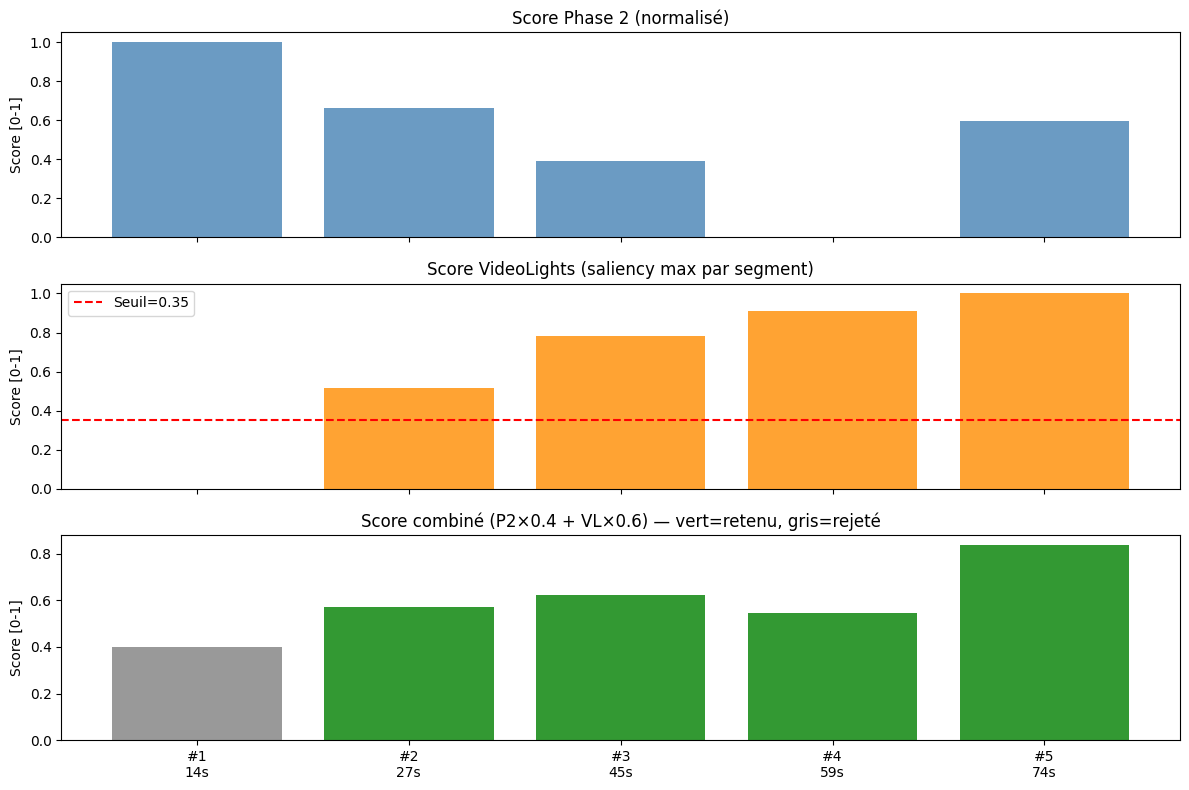

✅ Visualisation sauvegardée : /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_phase4_vl_scores.png


In [24]:
# ============================================================
# CELL 11 : Score combiné P2 + VideoLights & Sélection finale
# ============================================================
import matplotlib.pyplot as plt

# Normaliser les scores P2 sur [0..1]
p2_scores_norm = (hl_scores - hl_scores.min()) / (hl_scores.max() - hl_scores.min() + 1e-8)

# Score combiné : 40% P2 + 60% VideoLights
W_P2 = 0.40
W_VL = 0.60
combined_scores = W_P2 * p2_scores_norm + W_VL * segment_vl_scores

for i, d in enumerate(segment_vl_detail):
    d['combined_score'] = float(combined_scores[i])

# ── Sélection des segments à garder ───────────────────────
THRESH = CFG4['VL_SALIENCY_THRESH']
TOP_K  = CFG4['VL_TOP_K']

if TOP_K is not None:
    # Garder exactement top-K
    sorted_idx = np.argsort(combined_scores)[::-1][:TOP_K]
    kept_mask  = np.zeros(K, dtype=bool)
    kept_mask[sorted_idx] = True
    filter_mode = f'Top-{TOP_K}'
else:
    # Garder ceux au-dessus du seuil VL
    kept_mask  = segment_vl_scores >= THRESH
    filter_mode = f'Seuil VL >= {THRESH}'

# Garantir qu'on garde au moins 1 segment
if kept_mask.sum() == 0:
    best_idx = int(np.argmax(combined_scores))
    kept_mask[best_idx] = True
    print('⚠️  Aucun segment au-dessus du seuil → garde le meilleur')

# Appliquer en ordre chronologique
kept_indices = [i for i in range(K) if kept_mask[i]]
rejected_indices = [i for i in range(K) if not kept_mask[i]]

print(f'Mode filtrage : {filter_mode}')
print(f'Segments retenus   : {len(kept_indices)} / {K}')
print(f'Segments rejetés   : {len(rejected_indices)}')
print()
print('Résumé :')
print(f'{"Stat":<6} {"#":<4} {"Start":>7} {"End":>7}  {"VL":>6}  {"P2":>6}  {"Comb":>6}')
print('-' * 55)
for i, d in enumerate(segment_vl_detail):
    status = '✅ KEEP' if kept_mask[i] else '❌ DROP'
    print(f'{status}  #{i+1:<3} {d["orig_start"]:>6.1f}s {d["orig_end"]:>6.1f}s  '
          f'{d["vl_score_max"]:>6.3f}  {d["p2_score"]:>6.3f}  {d["combined_score"]:>6.3f}')

# ── Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
x = np.arange(K)
labels = [f'#{i+1}\n{d["orig_start"]:.0f}s' for i, d in enumerate(segment_vl_detail)]

axes[0].bar(x, p2_scores_norm, color='steelblue', alpha=0.8)
axes[0].set_title('Score Phase 2 (normalisé)')
axes[0].set_ylabel('Score [0-1]')

axes[1].bar(x, segment_vl_scores, color='darkorange', alpha=0.8)
axes[1].axhline(THRESH, color='red', linestyle='--', label=f'Seuil={THRESH}')
axes[1].set_title('Score VideoLights (saliency max par segment)')
axes[1].set_ylabel('Score [0-1]')
axes[1].legend()

colors = ['green' if kept_mask[i] else 'gray' for i in range(K)]
axes[2].bar(x, combined_scores, color=colors, alpha=0.8)
axes[2].set_title(f'Score combiné (P2×{W_P2} + VL×{W_VL}) — vert=retenu, gris=rejeté')
axes[2].set_ylabel('Score [0-1]')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)

plt.tight_layout()
viz_path = os.path.join(OUTPUT_DIR, VIDEO_STEM + '_phase4_vl_scores.png')
plt.savefig(viz_path, dpi=120)
plt.show()
print(f'✅ Visualisation sauvegardée : {viz_path}')

In [25]:
# ============================================================
# CELL 12 : Sauvegarder les résultats Phase 4
# ============================================================
P4_PATH = os.path.join(OUTPUT_DIR, VIDEO_STEM + '_phase4_highlights.npz')

kept_times  = np.array([[d['orig_start'], d['orig_end']] for i, d in enumerate(segment_vl_detail) if kept_mask[i]])
kept_scores = combined_scores[kept_mask]
kept_texts  = np.array([d['text'] for i, d in enumerate(segment_vl_detail) if kept_mask[i]])
kept_vl_sc  = segment_vl_scores[kept_mask]
kept_p2_sc  = hl_scores[kept_mask]

np.savez(
    P4_PATH,
    times         = kept_times,
    combined_score= kept_scores,
    vl_score      = kept_vl_sc,
    p2_score      = kept_p2_sc,
    raw_text      = kept_texts,
    query         = np.array([CFG4['VL_QUERY']]),
    filter_mode   = np.array([filter_mode]),
)
print(f'✅ Phase 4 sauvegardée : {P4_PATH}')
print(f'   {len(kept_times)} segments | durée = {(kept_times[:,1]-kept_times[:,0]).sum():.1f}s')

✅ Phase 4 sauvegardée : /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_phase4_highlights.npz
   4 segments | durée = 12.0s


In [26]:
# ============================================================
# CELL 13 : Extraire et recadrer les clips Phase 4 (portrait 9:16)
# ============================================================
CLIPS4_DIR = '/tmp/vl_clips_p4'
os.makedirs(CLIPS4_DIR, exist_ok=True)

OUT_W, OUT_H = map(int, CFG4['OUTPUT_RESOLUTION'].split('x'))
TARGET_DUR   = CFG4['TARGET_DURATION_S']

def extract_clip_portrait(video_path, start_s, end_s, out_path, w, h, fps):
    """Découpe + recadrage portrait 9:16 + resize."""
    dur = end_s - start_s
    vf  = f'crop=ih*{w}/{h}:ih,scale={w}:{h}:flags=lanczos,fps={fps}'
    cmd = [
        'ffmpeg', '-y', '-ss', str(start_s), '-i', video_path,
        '-t', str(dur), '-vf', vf,
        '-c:v', 'libx264', '-preset', 'fast', '-crf', '18',
        '-c:a', 'aac', '-b:a', '128k', '-movflags', '+faststart',
        out_path, '-loglevel', 'error'
    ]
    subprocess.run(cmd, check=True)

def add_caption(clip_path, caption, out_path, w, h):
    """Ajoute une légende en bas du clip."""
    safe = caption.replace("'", '').replace(':', ' ').replace('%', 'pct')[:80]
    fs   = max(24, w // 32)
    mg   = h // 20
    vf   = (f"drawtext=text='{safe}':fontsize={fs}:fontcolor=white"
            f":bordercolor=black:borderw=3:x=(w-text_w)/2:y=h-text_h-{mg}"
            f":box=1:boxcolor=black@0.5:boxborderw=10")
    cmd = [
        'ffmpeg', '-y', '-i', clip_path, '-vf', vf,
        '-c:v', 'libx264', '-preset', 'fast', '-crf', '18',
        '-c:a', 'copy', out_path, '-loglevel', 'error'
    ]
    subprocess.run(cmd, check=True)

clip_paths_p4 = []
total_dur_p4  = 0.0

print(f'Extraction clips Phase 4 ({len(kept_times)} segments)...')
for rank, ((start_s, end_s), text) in enumerate(zip(kept_times, kept_texts)):
    remaining   = TARGET_DUR - total_dur_p4
    if remaining <= 0:
        print(f'  → Durée cible atteinte ({TARGET_DUR}s), arrêt')
        break
    actual_end = min(end_s, start_s + remaining)
    dur        = actual_end - start_s
    out_clip   = os.path.join(CLIPS4_DIR, f'p4_clip_{rank+1:02d}.mp4')
    extract_clip_portrait(VIDEO_PATH, start_s, actual_end, out_clip, OUT_W, OUT_H, CFG4['OUTPUT_FPS'])

    if CFG4['ADD_CAPTIONS']:
        cap_path = out_clip.replace('.mp4', '_cap.mp4')
        caption  = str(text).split(' | ')[0]
        add_caption(out_clip, caption, cap_path, OUT_W, OUT_H)
        clip_paths_p4.append(cap_path)
    else:
        clip_paths_p4.append(out_clip)

    total_dur_p4 += dur
    vl_s = kept_vl_sc[rank] if rank < len(kept_vl_sc) else 0.0
    print(f'  Clip {rank+1:02d}: [{start_s:.1f}s → {actual_end:.1f}s]  ({dur:.1f}s)  VL={vl_s:.3f}')

print(f'\n✅ {len(clip_paths_p4)} clips extraits — durée totale = {total_dur_p4:.1f}s')

Extraction clips Phase 4 (4 segments)...
  Clip 01: [27.0s → 30.0s]  (3.0s)  VL=0.514
  Clip 02: [45.0s → 48.0s]  (3.0s)  VL=0.781
  Clip 03: [59.0s → 62.0s]  (3.0s)  VL=0.909
  Clip 04: [74.0s → 77.0s]  (3.0s)  VL=1.000

✅ 4 clips extraits — durée totale = 12.0s


In [27]:
# ============================================================
# CELL 14 : Assemblage final avec xfade transitions
# ============================================================

def get_duration(path):
    r = subprocess.run(
        ['ffprobe', '-v', 'error', '-show_entries', 'format=duration',
         '-of', 'csv=p=0', path],
        capture_output=True, text=True
    )
    return float(r.stdout.strip())

def assemble_xfade(clip_paths, fade_dur, output_path):
    """Assemble les clips avec transitions xfade."""
    if len(clip_paths) == 1:
        shutil.copy(clip_paths[0], output_path)
        return

    durations = [get_duration(p) for p in clip_paths]
    inputs = []
    for p in clip_paths:
        inputs += ['-i', p]

    fv, fa = [], []
    pv, pa = '[0:v]', '[0:a]'
    offset = 0.0

    for i in range(1, len(clip_paths)):
        offset += durations[i-1] - fade_dur
        is_last = (i == len(clip_paths) - 1)
        ov = '[vout]' if is_last else f'[v{i}]'
        oa = '[aout]' if is_last else f'[a{i}]'
        fv.append(f'{pv}[{i}:v]xfade=transition=fade:duration={fade_dur}:offset={offset:.3f}{ov}')
        fa.append(f'{pa}[{i}:a]acrossfade=d={fade_dur}{oa}')
        pv, pa = ov, oa

    fc  = ';'.join(fv + fa)
    cmd = ['ffmpeg', '-y'] + inputs + [
        '-filter_complex', fc,
        '-map', '[vout]', '-map', '[aout]',
        '-c:v', 'libx264', '-preset', 'fast', '-crf', '18',
        '-c:a', 'aac', '-b:a', '192k', '-movflags', '+faststart',
        output_path, '-loglevel', 'error'
    ]
    subprocess.run(cmd, check=True)

# ── Short chronologique (défaut) ──────────────────────────
SHORT_P4_PATH = os.path.join(OUTPUT_DIR, VIDEO_STEM + '_short_phase4.mp4')
print(f'Assemblage short Phase 4 ({len(clip_paths_p4)} clips)...')
assemble_xfade(clip_paths_p4, CFG4['FADE_DURATION_S'], SHORT_P4_PATH)
final_dur = get_duration(SHORT_P4_PATH)
print(f'✅ Short Phase 4 assemblé : {SHORT_P4_PATH}')
print(f'   Durée : {final_dur:.1f}s | {CFG4["OUTPUT_RESOLUTION"]} @ {CFG4["OUTPUT_FPS"]}fps')

Assemblage short Phase 4 (4 clips)...
✅ Short Phase 4 assemblé : /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_short_phase4.mp4
   Durée : 10.6s | 1080x1920 @ 30fps


In [28]:
# ============================================================
# CELL 15 : Ordre viral Phase 4  (hook → développement → climax)
# ============================================================

def viral_reorder_p4(clip_paths, times, scores):
    """
    Réordonne les clips pour un format viral :
    - Position 0  : hook    = 2ème meilleur score (accroche)
    - Position 1..N-2 : dev = autres en ordre chronologique
    - Position N-1 : climax = meilleur score absolu
    """
    K = len(clip_paths)
    if K == 1:
        return clip_paths, times, scores, ['climax']
    if K == 2:
        order  = np.argsort(scores)[::-1]
        idx    = [order[1], order[0]]
        labels = ['hook', 'climax']
        return [clip_paths[i] for i in idx], times[idx], scores[idx], labels

    order    = np.argsort(scores)[::-1]
    best_idx = order[0]
    hook_idx = order[1]
    dev_idx  = sorted([i for i in range(K) if i not in (best_idx, hook_idx)],
                      key=lambda i: times[i][0])
    final_idx    = [hook_idx] + dev_idx + [best_idx]
    final_labels = ['hook'] + ['dev'] * len(dev_idx) + ['climax']

    return ([clip_paths[i] for i in final_idx],
            times[final_idx],
            scores[final_idx],
            final_labels)


viral_clips, viral_times, viral_scores, viral_labels = viral_reorder_p4(
    clip_paths_p4, kept_times[:len(clip_paths_p4)], kept_scores[:len(clip_paths_p4)]
)

print('Ordre viral Phase 4:')
for pos, (label, t, sc) in enumerate(zip(viral_labels, viral_times, viral_scores)):
    emoji = {'hook': '🎣', 'dev': '📖', 'climax': '🔥'}.get(label, '')
    print(f'  {pos+1}. {emoji} {label:<8}  [{t[0]:.1f}s → {t[1]:.1f}s]  score={sc:.3f}')

SHORT_P4_VIRAL = os.path.join(OUTPUT_DIR, VIDEO_STEM + '_short_phase4_viral.mp4')
print(f'\nAssemblage short viral Phase 4...')
assemble_xfade(viral_clips, CFG4['FADE_DURATION_S'], SHORT_P4_VIRAL)
viral_dur = get_duration(SHORT_P4_VIRAL)
print(f'✅ Short viral Phase 4 : {SHORT_P4_VIRAL}')
print(f'   Durée : {viral_dur:.1f}s')

Ordre viral Phase 4:
  1. 🎣 hook      [45.0s → 48.0s]  score=0.624
  2. 📖 dev       [27.0s → 30.0s]  score=0.574
  3. 📖 dev       [59.0s → 62.0s]  score=0.546
  4. 🔥 climax    [74.0s → 77.0s]  score=0.839

Assemblage short viral Phase 4...
✅ Short viral Phase 4 : /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_short_phase4_viral.mp4
   Durée : 10.6s


In [29]:
# ============================================================
# CELL 16 : Nettoyage + Rapport final complet
# ============================================================
shutil.rmtree(ASSEMBLE_DIR, ignore_errors=True)
shutil.rmtree(CLIPS4_DIR,   ignore_errors=True)
print('Fichiers temporaires supprimés')

print()
print('=' * 70)
print('  RAPPORT PIPELINE COMPLET (Phase 1 → 4)')
print('=' * 70)
print(f'  Source video         : {TARGET_VIDEO}')
print(f'  Phase 2 segments     : {K}  (entrée Phase 4)')
print(f'  Query VideoLights    : "{CFG4["VL_QUERY"]}"')
print(f'  Filtrage             : {filter_mode}')
print(f'  Phase 4 segments     : {len(kept_times)} retenus / {K} entrée')
print(f'  Poids scoring        : P2×{W_P2} + VideoLights×{W_VL}')
print()
print(f'  Outputs :')
print(f'    _phase4_highlights.npz        → données Phase 4')
print(f'    _short_phase4.mp4             → short chronologique ({final_dur:.1f}s)')
print(f'    _short_phase4_viral.mp4       → short viral ({viral_dur:.1f}s)')
print(f'    _assembled_highlights.mp4     → vidéo assemblée (input VL)')
print(f'    _phase4_vl_scores.png         → visualisation scores')
print(f'  Résolution           : {CFG4["OUTPUT_RESOLUTION"]} portrait 9:16 @ {CFG4["OUTPUT_FPS"]}fps')
print('=' * 70)
print()
print('Highlights Phase 4 (chronologique):')
for i, (t, vl_s, p2_s, c_s) in enumerate(zip(kept_times, kept_vl_sc, kept_p2_sc, kept_scores)):
    dur = t[1] - t[0]
    print(f'  [{i+1}] {t[0]:>6.1f}s → {t[1]:>6.1f}s  ({dur:.1f}s)  '
          f'VL={vl_s:.3f}  P2={p2_s:.3f}  Comb={c_s:.3f}')

Fichiers temporaires supprimés

  RAPPORT PIPELINE COMPLET (Phase 1 → 4)
  Source video         : Obama_Yes_we_can.mp4
  Phase 2 segments     : 5  (entrée Phase 4)
  Query VideoLights    : "exciting highlight moment"
  Filtrage             : Seuil VL >= 0.35
  Phase 4 segments     : 4 retenus / 5 entrée
  Poids scoring        : P2×0.4 + VideoLights×0.6

  Outputs :
    _phase4_highlights.npz        → données Phase 4
    _short_phase4.mp4             → short chronologique (10.6s)
    _short_phase4_viral.mp4       → short viral (10.6s)
    _assembled_highlights.mp4     → vidéo assemblée (input VL)
    _phase4_vl_scores.png         → visualisation scores
  Résolution           : 1080x1920 portrait 9:16 @ 30fps

Highlights Phase 4 (chronologique):
  [1]   27.0s →   30.0s  (3.0s)  VL=0.514  P2=0.569  Comb=0.574
  [2]   45.0s →   48.0s  (3.0s)  VL=0.781  P2=0.560  Comb=0.624
  [3]   59.0s →   62.0s  (3.0s)  VL=0.909  P2=0.548  Comb=0.546
  [4]   74.0s →   77.0s  (3.0s)  VL=1.000  P2=0.567  C